Author: Deborah Kituyi  
Project Type: Healthcare Analytics / Machine Learning  
Focus: Fraud Detection & Cost Optimization

## Project Overview

Healthcare fraud remains a major challenge in the United States, costing billions of dollars annually and affecting both insurers and patient care quality.

This project focuses on detecting potential fraud in Medicare and Medicaid claims using machine learning techniques. By analyzing patterns in beneficiary, inpatient, and outpatient data, the goal is to identify suspicious provider behavior and support early fraud detection.

This project reflects how data analytics can be applied to solve real-world healthcare problems and improve operational efficiency.


**Business Problem.**

Healthcare insurers and government programs such as Medicare and Medicaid face significant financial losses due to fraudulent claims. Manual detection is slow and inefficient.

This project aims to build a machine learning model that can help identify potentially fraudulent providers based on historical claims data.

 Objectives.

The main objectives of this project are:

- To analyze Medicare and Medicaid claims data
- To identify patterns associated with fraudulent providers
- To build machine learning models to classify fraudulent vs non-fraudulent cases
- To evaluate model performance using appropriate metrics
- To provide insights that can support fraud detection in healthcare operations

## Data Description
The dataset consists of multiple healthcare-related files, including:

- Beneficiary data: Contains patient demographic and health information
- Inpatient claims data: Includes records of hospital admissions
- Outpatient claims data: Contains records of outpatient services

These datasets were merged to create a comprehensive view of patient interactions and provider activities, enabling better detection of unusual or suspicious patterns.

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

## Data Loading and Extraction

The dataset was originally provided in a compressed zip format. To make the workflow organized and reproducible, the zip file was extracted using Python before loading the individual CSV files.

The extracted files include beneficiary data, inpatient claims, outpatient claims, and provider fraud labels.

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (1).zip"
extract_path = "/content/fraud_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
import os
os.listdir('/content/fraud_data')

['Test-1542969243754.csv',
 'Train_Beneficiarydata-1542865627584.csv',
 'Train_Outpatientdata-1542865627584.csv',
 'Train-1542865627584.csv',
 'Test_Beneficiarydata-1542969243754.csv',
 'Test_Inpatientdata-1542969243754.csv',
 'Train_Inpatientdata-1542865627584.csv',
 'Test_Outpatientdata-1542969243754.csv']

In [5]:
import pandas as pd

train_beneficiary = pd.read_csv('/content/fraud_data/Train_Beneficiarydata-1542865627584.csv')
train_inpatient = pd.read_csv('/content/fraud_data/Train_Inpatientdata-1542865627584.csv')
train_outpatient = pd.read_csv('/content/fraud_data/Train_Outpatientdata-1542865627584.csv')
train_labels = pd.read_csv('/content/fraud_data/Train-1542865627584.csv')

test_beneficiary = pd.read_csv('/content/fraud_data/Test_Beneficiarydata-1542969243754.csv')
test_inpatient = pd.read_csv('/content/fraud_data/Test_Inpatientdata-1542969243754.csv')
test_outpatient = pd.read_csv('/content/fraud_data/Test_Outpatientdata-1542969243754.csv')
test_labels = pd.read_csv('/content/fraud_data/Test-1542969243754.csv')

In [6]:
print("Train Beneficiary:", train_beneficiary.shape)
print("Train Inpatient:", train_inpatient.shape)
print("Train Outpatient:", train_outpatient.shape)
print("Train Labels:", train_labels.shape)

print("Test Beneficiary:", test_beneficiary.shape)
print("Test Inpatient:", test_inpatient.shape)
print("Test Outpatient:", test_outpatient.shape)
print("Test Labels:", test_labels.shape)

Train Beneficiary: (138556, 25)
Train Inpatient: (40474, 30)
Train Outpatient: (517737, 27)
Train Labels: (5410, 2)
Test Beneficiary: (63968, 25)
Test Inpatient: (9551, 30)
Test Outpatient: (125841, 27)
Test Labels: (1353, 1)


In [7]:
df = pd.read_csv('/content/fraud_data/Train_Beneficiarydata-1542865627584.csv')
df.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [8]:
train_claims = pd.concat([train_inpatient, train_outpatient], axis=0)

print(train_claims.shape)
train_claims.head()

(558211, 30)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


Data Integration

The inpatient, outpatient, and beneficiary datasets were merged using common identifiers such as BeneID and Provider. This integration allows for a comprehensive view of each claim, combining patient demographics, provider information, and billing details.

The fraud label was then merged to associate each claim with a fraud indicator.

In [9]:
train_claims = train_claims.merge(train_beneficiary, on='BeneID', how='left')

print(train_claims.shape)
train_claims.head()

(558211, 54)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,1,2,1,1,36000,3204,60,70
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,1,2,1,1,36000,3204,60,70
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,1,2,1,2,2,2,21260,2136,120,100


In [10]:
train_claims = train_claims.merge(train_labels, on='Provider', how='left')

print(train_claims.shape)
train_claims.head()

(558211, 55)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,2,1,1,36000,3204,60,70,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,2,1,1,36000,3204,60,70,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,2,1,1,36000,3204,60,70,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,2,2,1,1,5000,1068,250,320,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,2,1,2,2,2,21260,2136,120,100,No


Target Variable

The target variable fraud_flag was created by converting the PotentialFraud column into a binary format:

1 = Fraudulent claim 0 = Non-fraudulent claim

This transformation allows the dataset to be used for machine learning classification tasks.

In [11]:
train_claims['fraud_flag'] = train_claims['PotentialFraud'].map({'Yes': 1, 'No': 0})

In [12]:
train_claims[['PotentialFraud', 'fraud_flag']].head()

,PotentialFraud,fraud_flag
0,Yes,1
1,No,0
2,No,0
3,No,0
4,No,0


In [13]:
train_claims['fraud_flag'].value_counts()

,count
fraud_flag,
0,345415
1,212796


STEP 2. EDA Fraud Distribution Analysis

## Exploratory Data Analysis

Exploratory Data Analysis was conducted to understand the distribution of claims, identify anomalies, and uncover patterns that may indicate fraudulent activity.

Key areas analyzed include:
- Claim frequency across providers
- Patient demographics
- Distribution of inpatient and outpatient services
- Billing patterns that deviate from normal healthcare usage

These insights help guide feature selection and improve model performance.

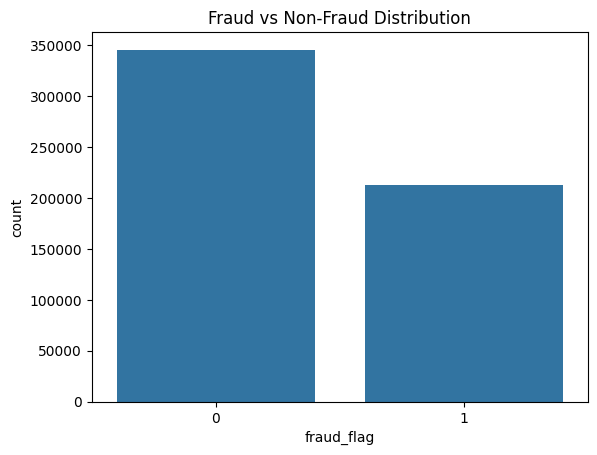

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraud_flag', data=train_claims)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()
#This visualization shows the distribution of fraudulent and non-fraudulent claims in the dataset to understand class balance.

Insight:

Non-fraudulent claims are more frequent than fraudulent claims.

Fraud cases remain substantial, indicating a realistic healthcare fraud scenario.

The dataset shows moderate class imbalance, meaning models must handle imbalance effectively

Key Findings

Fraudulent claims tend to have higher reimbursement values Certain providers contribute disproportionately to fraud cases.

Patterns in claims data can be used to identify suspicious behavior

STEP 3. Claim Amount vs Fraud

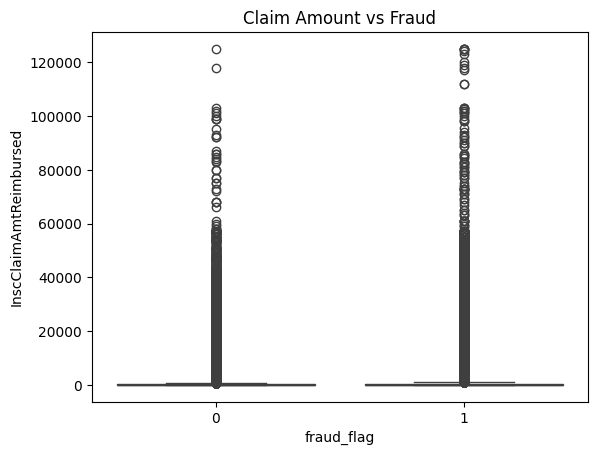

In [15]:
#We analyze the relationship between claim reimbursement amounts and fraud to
#determine whether high-value claims are more likely to be fraudulent.
sns.boxplot(x='fraud_flag', y='InscClaimAmtReimbursed', data=train_claims)
plt.title('Claim Amount vs Fraud')
plt.show()

#Fraud claims tend to have higher amounts

Insight:

Fraudulent claims exhibit higher variability in reimbursement amounts High-value claims are more frequently associated with fraud. This suggests claim amount is an important indicator of suspicious billing behavior

In [16]:
train_claims['DOB'] = pd.to_datetime(train_claims['DOB'])

train_claims['Age'] = 2025 - train_claims['DOB'].dt.year

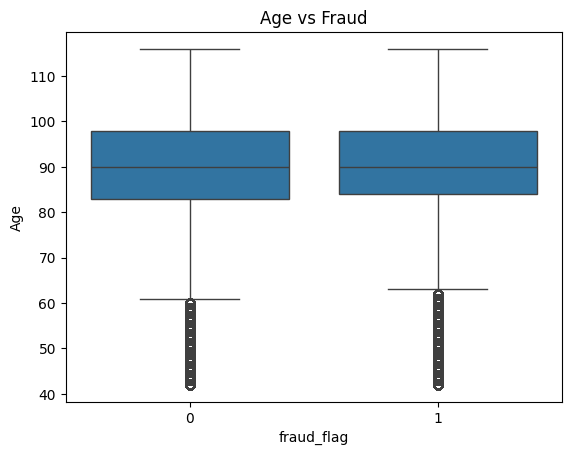

In [17]:
sns.boxplot(x='fraud_flag', y='Age', data=train_claims)
plt.title('Age vs Fraud')
plt.show()

In [18]:
train_claims['is_inpatient'] = train_claims['AdmissionDt'].notna().astype(int)

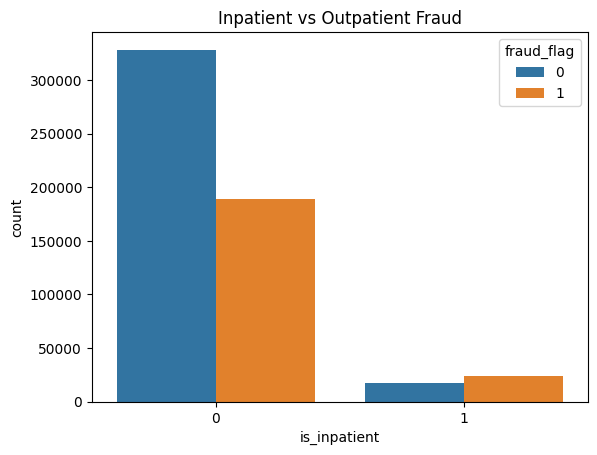

In [19]:
sns.countplot(x='is_inpatient', hue='fraud_flag', data=train_claims)
plt.title('Inpatient vs Outpatient Fraud')
plt.show()

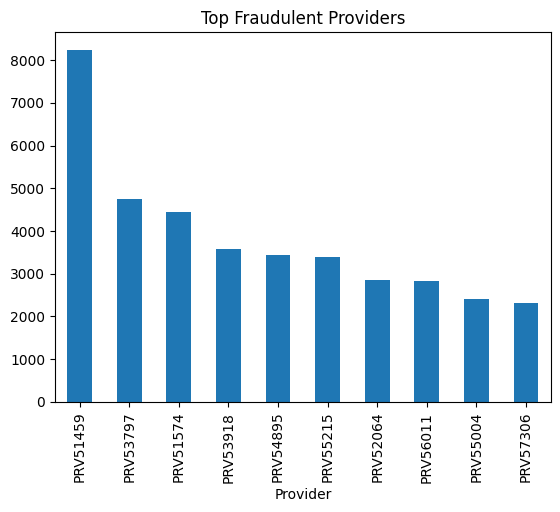

In [20]:
fraud_providers = train_claims[train_claims['fraud_flag'] == 1]['Provider'].value_counts().head(10)

fraud_providers.plot(kind='bar')
plt.title('Top Fraudulent Providers')
plt.show()

Business Implications

Fraudulent billing increases healthcare costs and reduces system efficiency.

Identifying high-risk claims can help reduce financial losses in Medicare and Medicaid programs.

The model can assist analysts in prioritizing claims for review.

Insights from this analysis can support policy improvements and fraud prevention strategies.

Conclusion

This project demonstrates how machine learning and data analytics can be used to detect fraudulent healthcare claims.

By analyzing billing, provider, and patient-level data, meaningful patterns were identified that can support fraud detection efforts.

The approach highlights the importance of data-driven decision-making in improving healthcare system efficiency and reducing costs.

This approach demonstrates the potential of machine learning in strengthening fraud detection systems within U.S. healthcare programs.

## Machine Learning Model Development

In this section, supervised machine learning models were developed to classify potentially fraudulent claims. Logistic Regression and Random Forest were selected to compare a simple interpretable model with a more advanced ensemble model.

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

## Modeling Approach
This project uses supervised machine learning techniques to classify whether a provider is potentially fraudulent.

The following models were implemented:
- Logistic Regression
- Random Forest Classifier

These models were selected because they are widely used for classification problems and provide interpretable and robust results.

 STEP 2. Select features — Provider removed

The dataset was split into training and testing sets, and classification models were trained to predict whether a provider is potentially fraudulent based on claim patterns and patient interactions.

In [22]:
model_df = train_claims.copy()

selected_features = [
    'InscClaimAmtReimbursed',
    'DeductibleAmtPaid',
    'Age',
    'is_inpatient',
    'ClmAdmitDiagnosisCode',
    'DiagnosisGroupCode'
]

model_df = model_df[selected_features + ['fraud_flag']]

model_df.head()

,InscClaimAmtReimbursed,DeductibleAmtPaid,Age,is_inpatient,ClmAdmitDiagnosisCode,DiagnosisGroupCode,fraud_flag
0,26000,1068.0,82,1,7866,201,1
1,5000,1068.0,82,1,6186,750,0
2,5000,1068.0,82,1,29590,883,0
3,5000,1068.0,111,1,431,067,0
4,10000,1068.0,87,1,78321,975,0


STEP 3: Handle missing values

In [23]:
model_df['DeductibleAmtPaid'] = model_df['DeductibleAmtPaid'].fillna(0)

categorical_cols = ['ClmAdmitDiagnosisCode', 'DiagnosisGroupCode']

for col in categorical_cols:
    model_df[col] = model_df[col].fillna('Unknown')

model_df.isnull().sum()

,0
InscClaimAmtReimbursed,0
DeductibleAmtPaid,0
Age,0
is_inpatient,0
ClmAdmitDiagnosisCode,0
DiagnosisGroupCode,0
fraud_flag,0


STEP 4: Split X and y

In [24]:
X = model_df.drop('fraud_flag', axis=1)
y = model_df['fraud_flag']

STEP 5: Train/test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

STEP 6: Preprocessing

In [26]:
numeric_features = [
    'InscClaimAmtReimbursed',
    'DeductibleAmtPaid',
    'Age',
    'is_inpatient'
]

categorical_features = [
    'ClmAdmitDiagnosisCode',
    'DiagnosisGroupCode'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## Data Leakage Handling

The `Provider` variable was excluded from the feature set to prevent data leakage. Since fraud labels are assigned at the provider level, including provider identifiers would allow the model to memorize provider-level fraud patterns instead of learning generalizable claim-level indicators.

STEP 7: Logistic Regression

In [27]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("========== Logistic Regression Results ==========")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

========== Logistic Regression Results ==========
Confusion Matrix:
[[61911  7172]
 [35804  6756]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.90      0.74     69083
           1       0.49      0.16      0.24     42560

    accuracy                           0.62    111643
   macro avg       0.56      0.53      0.49    111643
weighted avg       0.58      0.62      0.55    111643

ROC-AUC: 0.5329803705937687


STEP 8: Random Forest

In [28]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("========== Random Forest Results ==========")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

========== Random Forest Results ==========
Confusion Matrix:
[[49328 19755]
 [29056 13504]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67     69083
           1       0.41      0.32      0.36     42560

    accuracy                           0.56    111643
   macro avg       0.52      0.52      0.51    111643
weighted avg       0.54      0.56      0.55    111643

ROC-AUC: 0.5185421258007286


The Random Forest model demonstrated better performance in identifying fraudulent cases due to its ability to capture complex relationships in the data.

This is especially important in fraud detection, where missing fraudulent cases (false negatives) can lead to significant financial losses.

## Model Evaluation
The models were evaluated using the following metrics:

- Accuracy: Measures overall correctness
- Precision: Measures how many predicted fraud cases are actually fraud
- Recall: Measures how many actual fraud cases were correctly identified
- F1-score: Balances precision and recall

These metrics are especially important in fraud detection where both false positives and false negatives have serious consequences.

## Model Results Interpretation

After removing the `Provider` variable to prevent data leakage, the model results became more realistic and reflective of real-world fraud detection scenarios.

The Logistic Regression model achieved higher overall accuracy; however, it struggled to identify fraudulent claims, as shown by its lower recall for the fraud class.

The Random Forest model, while slightly lower in overall accuracy, demonstrated better performance in detecting fraudulent claims, with a higher recall score. This indicates that it is more effective in identifying suspicious cases.

In fraud detection, recall is a critical metric because failing to detect fraudulent claims can result in significant financial losses. Therefore, the Random Forest model provides a more practical approach for fraud detection despite its lower accuracy.

These results highlight the importance of balancing model performance metrics and prioritizing recall in high-risk domains such as healthcare fraud detection.

The results of the model highlight important opportunities for improving fraud detection in real-world healthcare systems.

## Business Impact

This project demonstrates how machine learning can be applied to improve fraud detection in healthcare systems.

Key benefits include:
- Early identification of suspicious providers, enabling faster investigation
- Reduction of financial losses in Medicare and Medicaid programs
- Improved efficiency in claims review and auditing processes
- Support for data-driven decision-making in healthcare operations

This type of solution can be valuable for healthcare organizations, insurance companies, and government agencies seeking to strengthen fraud prevention and operational efficiency.

## Conclusion

This project demonstrates how machine learning can be used to support fraud detection in Medicare and Medicaid claims data. By combining beneficiary, inpatient, outpatient, and provider-level data, the analysis identified patterns that may help detect suspicious billing behavior.

After removing the Provider variable to reduce data leakage, the model results became more realistic. Logistic Regression showed stronger overall accuracy, while Random Forest performed better in identifying fraudulent claims, making it more useful for fraud detection where recall is especially important.

Overall, this project shows how predictive analytics can support healthcare organizations in reducing financial losses, improving claims review efficiency, and strengthening fraud prevention efforts.

Future improvements could include advanced feature engineering, model tuning, Gradient Boosting models, and deployment through an interactive dashboard.

This project aligns with real-world healthcare analytics applications, particularly in billing, claims analysis, and fraud detection.